In [1]:
from gam_rs_utils.utils import *
from src.rset_opt import RSetOPT
from src.run_app import get_models_from_rset
from method_scripts.results import Results
import random
import numpy as np
from sklearn.linear_model import LogisticRegression

dn = 'bank'
data = pd.read_csv(f'datasets/{dn}.csv')
l0 = 0.001
l2 = 0.001
m = 1.01

fastsparse_data = Results.create_fastsparse_dataset(dn, l0, l2)
cum_X = fastsparse_data['cum_X']
cum_header = fastsparse_data['cum_header']
bin_X = fastsparse_data['bin_X']
bin_header = fastsparse_data['bin_header']
y = fastsparse_data['y']
w = fastsparse_data['w']

print("data shape", data.shape)
print("cum_X shape", cum_X.shape)
print("w", len(w), "y", len(y), "header", len(cum_header), cum_header[:10])

loading dataset from results/bank/l0_0.001_l2_0.001.pkl
Loading cached fastsparse dataset for bank with l0=0.001 and l2=0.001
data shape (4521, 17)
cum_X shape (4521, 3719)
w 3719 y 4521 header 3719 Index(['intercept', 'age<=19', 'age<=20', 'age<=21', 'age<=22', 'age<=23',
       'age<=24', 'age<=25', 'age<=26', 'age<=27'],
      dtype='object')


### Support Set Sampling via Metropolis Hastings 

In [2]:
# ---------- 0. prepare data ----------

# cum_X: (n_samples, n_features) binary matrix
# y: (n_samples,) vector of -1/1 labels
# cum_header: list of feature names (len = n_features)

X = cum_X.values if hasattr(cum_X, "values") else cum_X
y_arr01 = y.values.astype(float) if hasattr(y, "values") else y.astype(float)
y_arr01 = (y_arr01 > 0).astype(int)

n, K = X.shape

# optional: always keep intercept (assume column 0)
INTERCEPT_IDX = 0

# ---------- 1. MAP logistic regression + Laplace score ---------- 

def map_logistic_theta(X_S, y, sigma2, max_iter=1000):
    # C is inverse of reg strength; C ≈ sigma2 is a rough mapping
    clf = LogisticRegression(
        penalty="l2",
        C=sigma2,
        fit_intercept=False,
        solver="lbfgs",
        max_iter=max_iter,
    )
    clf.fit(X_S, y)
    theta_hat = clf.coef_.ravel()
    proba = clf.predict_proba(X_S)[:, 1]
    return theta_hat, proba

def hessian_and_logdet(X_S, proba, sigma2, jitter=1e-6):
    # proba = π_i = P(y_i=1)
    p = np.clip(proba, 1e-8, 1.0 - 1e-8)
    W = p * (1.0 - p)          # (n,)
    XTW = X_S.T * W            # each row scaled by W
    A = XTW @ X_S + (1.0 / sigma2) * np.eye(X_S.shape[1])

    # add a tiny jitter on top of the prior to ensure positive definiteness
    A += jitter * np.eye(A.shape[0])

    # compute log det via Cholesky if possible
    try:
        L = np.linalg.cholesky(A)      # A = L L^T
        logdet = 2.0 * np.sum(np.log(np.diag(L)))
    except np.linalg.LinAlgError:
        print("np.linalg.LinAlgError")
        # fallback to slogdet
        sign, logdet = np.linalg.slogdet(A)
        if sign <= 0:
            # last resort: just make it something finite
            logdet = np.log(np.abs(np.linalg.det(A)) + 1e-12)

    return A, logdet

def evaluate_score_laplace(S, X, y, sigma2, p_feat, K, max_iter=1000):
    """
    J(S) ≈ log P(S) + log P(D | S, θ̂_S) + log P(θ̂_S) - 0.5 log det(A_S)
    """

    idx = np.array(sorted(list(S)), dtype=int)
    X_S = X[:, idx]
    n, d = X_S.shape

    # 1. MAP θ and probabilities
    theta_hat, proba = map_logistic_theta(X_S, y, sigma2=sigma2, max_iter=max_iter)

    # 2. log-likelihood at θ̂
    eps = 1e-12
    log_likelihood = np.sum(
        y * np.log(proba + eps) + (1.0 - y) * np.log(1.0 - proba + eps)
    )

    # 3. log prior on θ (Gaussian N(0, σ² I), constants dropped)
    log_prior_theta = -0.5 * np.dot(theta_hat, theta_hat) / sigma2

    # 4. Hessian and logdet for Laplace Occam factor
    _, logdet = hessian_and_logdet(X_S, proba, sigma2=sigma2)

    # 5. Laplace log-marginal (ignoring constants that cancel in MH)
    #    L(S) ≈ log_likelihood + log_prior_theta - 0.5 * logdet
    L_S = log_likelihood + log_prior_theta - 0.5 * logdet

    # 6. sparsity prior on S: Bernoulli(p_feat) per feature
    #    log P(S) = |S| log p_feat + (K - |S|) log(1 - p_feat)
    k = len(S)
    log_prior_S = k * np.log(p_feat) + (K - k) * np.log(1.0 - p_feat)

    # 7. total score
    J_S = L_S + log_prior_S

    return J_S, (log_likelihood, log_prior_theta, 0.5 * logdet, log_prior_S)

In [3]:
# ---------- 2. Proposal ---------- 
def propose_swap(S, K, score, intercept_idx=0, add_power=1.0, drop_power=1.0, eps=1e-8):
    """
    one-step proposal that preserves support size:
        - choose one non-intercept feature in S to remove
        - choose one feature outside S to add

    S            : current support (set of indices)
    K            : total number of features (0..K-1)
    intercept_idx: index of intercept column (kept fixed)
    """

    current = set(S)

    # all non-intercept indices
    all_features = set(range(K))
    all_features.discard(intercept_idx)

    in_set  = [j for j in current if j != intercept_idx]
    out_set = list(all_features - current)

    if len(in_set) == 0 or len(out_set) == 0:
        # degenerate: nothing to swap, return same support
        return current

    # pick one to drop, one to add
    f_remove = random.choice(in_set)
    f_add    = random.choice(out_set)

    S_prop = set(current)
    S_prop.remove(f_remove)
    S_prop.add(f_add)

    return S_prop, 0, 0

# ---------- 2. Proposal ---------- 
def compute_corr_score(X, y01, intercept_idx=0, eps=1e-12):
    """
    X   : numpy array (n, K), sparse-in-value but dense ndarray
    y01 : numpy array (n,), values in {0,1}
    returns:
      score : numpy array (K,), higher = more important
    """
    X = np.asarray(X, dtype=float)
    y01 = np.asarray(y01, dtype=float).ravel()

    n, K = X.shape

    # center y
    yc = y01 - y01.mean()
    y_norm = np.sqrt(np.sum(yc * yc)) + eps

    # center X columnwise
    X_mean = X.mean(axis=0)
    Xc = X - X_mean

    # numerator: X^T y
    Xt_y = Xc.T @ yc

    # denominator: ||X_j|| * ||y||
    X_norm = np.sqrt(np.sum(Xc * Xc, axis=0)) + eps

    score = np.abs(Xt_y / (X_norm * y_norm))

    # never bias intercept
    score[intercept_idx] = 0.0
    return score

def _normalize_weights(w):
    w = np.asarray(w, dtype=float)
    w = np.clip(w, 0.0, np.inf)
    s = w.sum()
    if not np.isfinite(s) or s <= 0:
        return np.ones_like(w) / len(w)
    return w / s

def propose_weighted_swap(
    S,
    K,
    score,
    intercept_idx=0,
    add_power=1.0,
    drop_power=1.0,
    eps=1e-12,
):
    """
    weighted 1-swap proposal:
      - drop one in-support (non-intercept) feature, biased toward low score
      - add one out-of-support (non-intercept) feature, biased toward high score

    returns:
      S_prop, log_q_forward, log_q_backward

    note: non-symmetric in general, so include (log_q_backward - log_q_forward) in MH
    """
    S = set(S)
    score = np.asarray(score, dtype=float)
    if score.shape[0] != K:
        raise ValueError(f"score must have length {K}, got {score.shape[0]}")

    # candidates from current state
    in_set = [j for j in S if j != intercept_idx]
    if len(in_set) == 0:
        return S, 0.0, 0.0

    out_set = [j for j in range(K) if (j not in S) and (j != intercept_idx)]
    if len(out_set) == 0:
        return S, 0.0, 0.0

    # forward drop probs: favor low score
    s_in = score[in_set]
    w_drop_fwd = (s_in + eps) ** (-drop_power)
    p_drop_fwd = _normalize_weights(w_drop_fwd)

    # forward add probs: favor high score
    s_out = score[out_set]
    w_add_fwd = (s_out + eps) ** (add_power)
    p_add_fwd = _normalize_weights(w_add_fwd)

    # sample move
    rng = np.random.default_rng()
    i_drop = rng.choice(len(in_set), p=p_drop_fwd)
    i_add = rng.choice(len(out_set), p=p_add_fwd)
    f_remove = in_set[i_drop]
    f_add = out_set[i_add]

    S_prop = set(S)
    S_prop.remove(f_remove)
    S_prop.add(f_add)

    log_q_forward = float(np.log(p_drop_fwd[i_drop]) + np.log(p_add_fwd[i_add]))

    # compute backward q: q(S | S_prop)
    # from S_prop, we'd need to remove f_add and add f_remove
    in_set_bwd = [j for j in S_prop if j != intercept_idx]
    out_set_bwd = [j for j in range(K) if (j not in S_prop) and (j != intercept_idx)]

    # sanity: required elements should exist
    if f_add not in in_set_bwd or f_remove not in out_set_bwd:
        log_q_backward = -np.inf
        return S_prop, log_q_forward, log_q_backward

    # backward drop probs (drop from S_prop): favors low score
    s_in_bwd = score[in_set_bwd]
    w_drop_bwd = (s_in_bwd + eps) ** (-drop_power)
    p_drop_bwd = _normalize_weights(w_drop_bwd)

    # backward add probs (add to S_prop): favors high score
    s_out_bwd = score[out_set_bwd]
    w_add_bwd = (s_out_bwd + eps) ** (add_power)
    p_add_bwd = _normalize_weights(w_add_bwd)

    i_drop_bwd = in_set_bwd.index(f_add)
    i_add_bwd = out_set_bwd.index(f_remove)

    log_q_backward = float(np.log(p_drop_bwd[i_drop_bwd]) + np.log(p_add_bwd[i_add_bwd]))

    return S_prop, log_q_forward, log_q_backward

In [4]:
# ---------- 3. Metropolis-Hastings ---------- 
def mh_sample_supports(
    X, 
    y, 
    sigma2=10.0, 
    n_steps=2000, 
    p_feat=0.01, 
    beta=0.025, 
    burn_in=500, 
    init_support=None, 
    intercept_idx=0,
    proposal_fnc=propose_swap,
):
    """
    Metropolis–Hastings sampler over supports of fixed size 'target_size_total'.

    X, y              : data
    sigma2            : prior variance on weights (L2 strength)
    target_size_total : total number of features in support (incl. intercept)
    n_steps           : total MH steps
    p_feat            : expected sparsity
    beta              : MH acceptance ratio parameter
    burn_in           : steps to discard
    init_support      : optional initial support (list/iterable of indices)
    intercept_idx     : index of intercept column
    proposal_fnc      : proposal function
    """

    n, K = X.shape

    # ---------- 1. initialize support ----------

    if init_support is not None:
        S_current = set(init_support)
        S_current.add(intercept_idx)
    else:
        S_current = {intercept_idx}

    # initial score
    J_current_raw, terms = evaluate_score_laplace(S_current, X, y, sigma2=sigma2, p_feat=p_feat, K=K)

    samples = []
    scores = []

    accepts = 0
    score = compute_corr_score(X, y, intercept_idx=intercept_idx)

    # ---------- 2. MCMC loop ----------
    for t in range(n_steps):
        # propose a swap that keeps |S| fixed
        S_prop, log_q_forward, log_q_backward = proposal_fnc(
            S_current, K, 
            score, 
            intercept_idx=intercept_idx, 
        )

        # evaluate proposed support
        J_prop_raw, terms = evaluate_score_laplace(S_prop, X, y, sigma2=sigma2, p_feat=p_feat, K=K)

        # MH acceptance ratio (log scale)
        log_alpha = beta * ((J_prop_raw - J_current_raw) + (log_q_backward - log_q_forward))

        u = np.random.rand()
        if np.log(u) < min(0.0, log_alpha):
            accepts += 1
            S_current = S_prop
            J_current_raw = J_prop_raw

        # store after burn-in
        if t >= burn_in:
            samples.append(sorted(list(set(S_current))))
            scores.append(J_current_raw)

        if (t + 1) % 100 == 0:
            acc_rate = accepts / (t+1)
            print(f"step {t+1}, |S|={len(S_current)}, J={J_current_raw:.2f} ({terms[0]:.2f}, {terms[1]:.2f}, {terms[2]:.2f}, {terms[3]:.2f}), accept_rate={acc_rate:.3f}")

    return samples, scores

def random_sample_supports(X, y, support_size, n_samples, sigma2=10.0, p_feat=0.01, intercept_idx=0):
    n, K = X.shape
    samples = []
    scores = []
    for t in range(n_samples):
        S_current = set(random.sample(range(K), support_size - 1))
        S_current.add(intercept_idx)
        J_current_raw, terms = evaluate_score_laplace(S_current, X, y, sigma2=sigma2, p_feat=p_feat, K=K)
        print(f"step {t+1}, |S|={len(S_current)}, J={J_current_raw:.2f} ({terms[0]:.2f}, {terms[1]:.2f}, {terms[2]:.2f}, {terms[3]:.2f})")
        samples.append(sorted(list(S_current)))
        scores.append(J_current_raw)
    return samples, scores

In [5]:
uniform_samples, uniform_scores = mh_sample_supports(
    X=X,
    y=y_arr01,
    sigma2=5.0,            # tune this if needed
    p_feat=0.01,
    beta=0.4,
    n_steps=2000,
    burn_in=500,
    init_support=w.nonzero()[0].tolist(),
    intercept_idx=INTERCEPT_IDX,
    proposal_fnc=propose_swap,
)

samples, scores = mh_sample_supports(
    X=X,
    y=y_arr01,
    sigma2=5.0,            # tune this if needed
    p_feat=0.01,
    beta=0.4,
    n_steps=2000,
    burn_in=500,
    init_support=w.nonzero()[0].tolist(),
    intercept_idx=INTERCEPT_IDX,
    proposal_fnc=propose_weighted_swap,
)

print("num samples:", len(samples))

random_samples, random_scores = random_sample_supports(
    X=X,
    y=y_arr01,
    support_size=len(w.nonzero()[0].tolist()),
    n_samples=30,
    sigma2=5.0,
)
print("num random samples:", len(random_samples))

step 100, |S|=13, J=-1209.54 (-1096.50, -3.58, 22.52, -97.11), accept_rate=0.140
step 200, |S|=13, J=-1230.15 (-1153.07, -1.52, 22.00, -97.11), accept_rate=0.170
step 300, |S|=13, J=-1227.35 (-1111.50, -3.42, 19.70, -97.11), accept_rate=0.187
step 400, |S|=13, J=-1234.32 (-1117.79, -2.91, 23.61, -97.11), accept_rate=0.212
step 500, |S|=13, J=-1240.12 (-1116.95, -3.22, 22.83, -97.11), accept_rate=0.254
step 600, |S|=13, J=-1234.15 (-1147.09, -2.52, 21.99, -97.11), accept_rate=0.252
step 700, |S|=13, J=-1243.15 (-1119.69, -3.75, 22.59, -97.11), accept_rate=0.249
step 800, |S|=13, J=-1242.13 (-1145.62, -4.40, 21.68, -97.11), accept_rate=0.250
step 900, |S|=13, J=-1246.39 (-1147.48, -2.35, 22.38, -97.11), accept_rate=0.253
step 1000, |S|=13, J=-1245.82 (-1124.60, -2.71, 21.39, -97.11), accept_rate=0.248
step 1100, |S|=13, J=-1243.48 (-1139.71, -2.27, 22.19, -97.11), accept_rate=0.245
step 1200, |S|=13, J=-1255.60 (-1134.59, -2.57, 21.33, -97.11), accept_rate=0.250
step 1300, |S|=13, J=-123

In [6]:
uniform_samples = uniform_samples[::50]
uniform_scores = uniform_scores[::50]

samples = samples[::50]
scores = scores[::50]

### Finetuning GAMs for each support set

In [8]:
sample = samples[0]
sample = sorted(list(sample))
w = np.zeros(K)
w[sample] = 1
sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)
sparse_gam_file = prepare_sparse_gam(dn, l0, l2, m, sparse_X, y, cum_header, sparse_header)

model = RSetOPT(sparse_gam_file)
model.finetune_ellipsoid()
H_opt = model.get_normalized_H()
model.update_file(H_opt, model.w_orig)

with open(sparse_gam_file, 'rb') as f:
    sparse_gam_data = pickle.load(f)

sparse_gam_data['w_orig']

objective: 0.2525688346945076 objective in LR 0.2525688346945076
m:1.01, log objective:0.2525688346945076, eps:0.25509452304145264
----------- before optimization -----------
volume proportional to  tensor(2.7492e+22, dtype=torch.float64, grad_fn=<MulBackward0>)
----------- after optimization -----------
volume proportional to  tensor(7.3868e+21, dtype=torch.float64, grad_fn=<MulBackward0>)


array([-0.45001243, -0.70312062, -0.3728747 , -0.11941718, -1.24828512,
       -0.49995458,  1.21056388, -3.92793203, -0.83160316,  0.41444412,
        0.69396277,  1.49961805,  3.11831664,  3.09757567,  2.9105489 ,
       -0.92074278,  1.687311  , -2.42943533, -0.09532711])

In [11]:
w = np.zeros(K)
w[sample] = 1
sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)

header_object = ModelUtils.get_header_object(cum_header)
sparse_header_object = ModelUtils.get_header_object(sparse_header)
expanded_theta = ModelUtils.expand_w(sparse_gam_data['w_orig'], sparse_header_object, header_object)

array([-0.45001243,  0.        ,  0.        , ..., -2.42943533,
       -0.09532711, -0.09532711])

In [55]:
all_w_samples = []
for sample_set in [uniform_samples, samples, random_samples]:
    w_samples = []
    for sample in sample_set:
        print(sample)
        w = np.zeros(K)
        w[sample] = 1
        sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)
        sparse_gam_file = prepare_sparse_gam(dn, l0, l2, m, sparse_X, y, cum_header, sparse_header)

        model = RSetOPT(sparse_gam_file)
        model.finetune_ellipsoid()
        H_opt = model.get_normalized_H()
        model.update_file(H_opt, model.w_orig)

        with open(sparse_gam_file, 'rb') as f:
            sparse_gam_data = pickle.load(f)

        w_samples.append(sparse_gam_data['w_orig'])
    all_w_samples.append(w_samples)

[0, 67, 92, 184, 1354, 1787, 2446, 2561, 2700, 2906, 3132, 3408, 3444]
objective: 0.2665507029063028 objective in LR 0.2665507029063028
m:1.01, log objective:0.2665507029063028, eps:0.2692162099353658
----------- before optimization -----------
volume proportional to  tensor(5.9677e+19, dtype=torch.float64, grad_fn=<MulBackward0>)
----------- after optimization -----------
volume proportional to  tensor(4.2867e+18, dtype=torch.float64, grad_fn=<MulBackward0>)
[0, 1340, 1661, 2001, 2407, 2446, 2561, 2700, 2813, 3132, 3408, 3444, 3533]
objective: 0.2649692398548721 objective in LR 0.2649692398548721
m:1.01, log objective:0.2649692398548721, eps:0.2676189322534208
----------- before optimization -----------
volume proportional to  tensor(4.2883e+19, dtype=torch.float64, grad_fn=<MulBackward0>)
----------- after optimization -----------
volume proportional to  tensor(9.2970e+18, dtype=torch.float64, grad_fn=<MulBackward0>)
[0, 585, 1621, 1647, 2446, 2561, 2700, 2813, 2871, 3132, 3165, 3408

In [144]:
print(all_w_samples[0][0])

[-0.61338527 -5.48322309 -0.97588985 -0.70812309 -0.31748119 -0.34241692
 -0.32252634 -1.13174063 -4.11940133 -1.01935833  0.47312367  1.21640968
  2.57842689 -0.77700274  1.59965969 -0.101608  ]


In [ ]:
def get_binned_w_samples(samples, w_samples):
    binned_w_samples = []
    losses = []
    for sample, theta in zip(samples, w_samples):
        w = np.zeros(K)
        w[sample] = 1
        sparse_X, sparse_header = utils.binary_to_one_hot(data.iloc[:,:-1], w, cum_header)

        header_object = ModelUtils.get_header_object(cum_header)
        sparse_header_object = ModelUtils.get_header_object(sparse_header)
        expanded_theta = ModelUtils.expand_w(theta, sparse_header_object, header_object)

        loss_a = ModelUtils.get_loss_one_model(
            sparse_X, y, 
            theta, 
            sample_p = Results.get_sample_proportion(sparse_X),
            loss_type='logistic', l2=0.001, 
        )
        # print(loss_a)

        loss_b = ModelUtils.get_loss_one_model(
            bin_X, y,
            expanded_theta, 
            sample_p = Results.get_sample_proportion(bin_X),
            loss_type='logistic', l2=0.001, 
        )
        # print(loss_b)
        
        # print(np.allclose(loss_a, loss_b))
        binned_w_samples.append(expanded_theta)
        losses.append(loss_a)

    binned_w_samples = np.vstack(binned_w_samples)
    return binned_w_samples, losses

binned_uniform_w_samples, uniform_losses = get_binned_w_samples(uniform_samples, all_w_samples[0])
binned_mcmc_w_samples, mcmc_losses = get_binned_w_samples(samples, all_w_samples[1])
binned_random_w_samples, random_losses = get_binned_w_samples(random_samples, all_w_samples[2])

In [142]:
uniform_samples[0]

[0, 870, 2442, 2447, 2451, 2579, 2699, 2848, 3093, 3187, 3543, 3691, 3716]

In [ ]:
binned_mcmc_w_samples.shape, len(bin_header)

(30, 3719)

In [35]:
binned_mcmc_w_samples[:,1:].shape, np.array(bin_header[1:]).shape

((30, 3718), (3718,))

### Plotting

In [16]:
fn_ellipsoid = 'ellipsoid_l0_0.001_l2_0.001_m_1.05_samples_1000_sampling_surface_distance_metric_None.pkl'
ellipsoid_result = Results.load_result(f"results/{dn}/method_results/{fn_ellipsoid}")

fn_swapping = 'swapping_l0_0.001_l2_1e-08_m_1.05_samples_100.pkl'
swapping_result = Results.load_result(f"results/{dn}/method_results/{fn_swapping}")

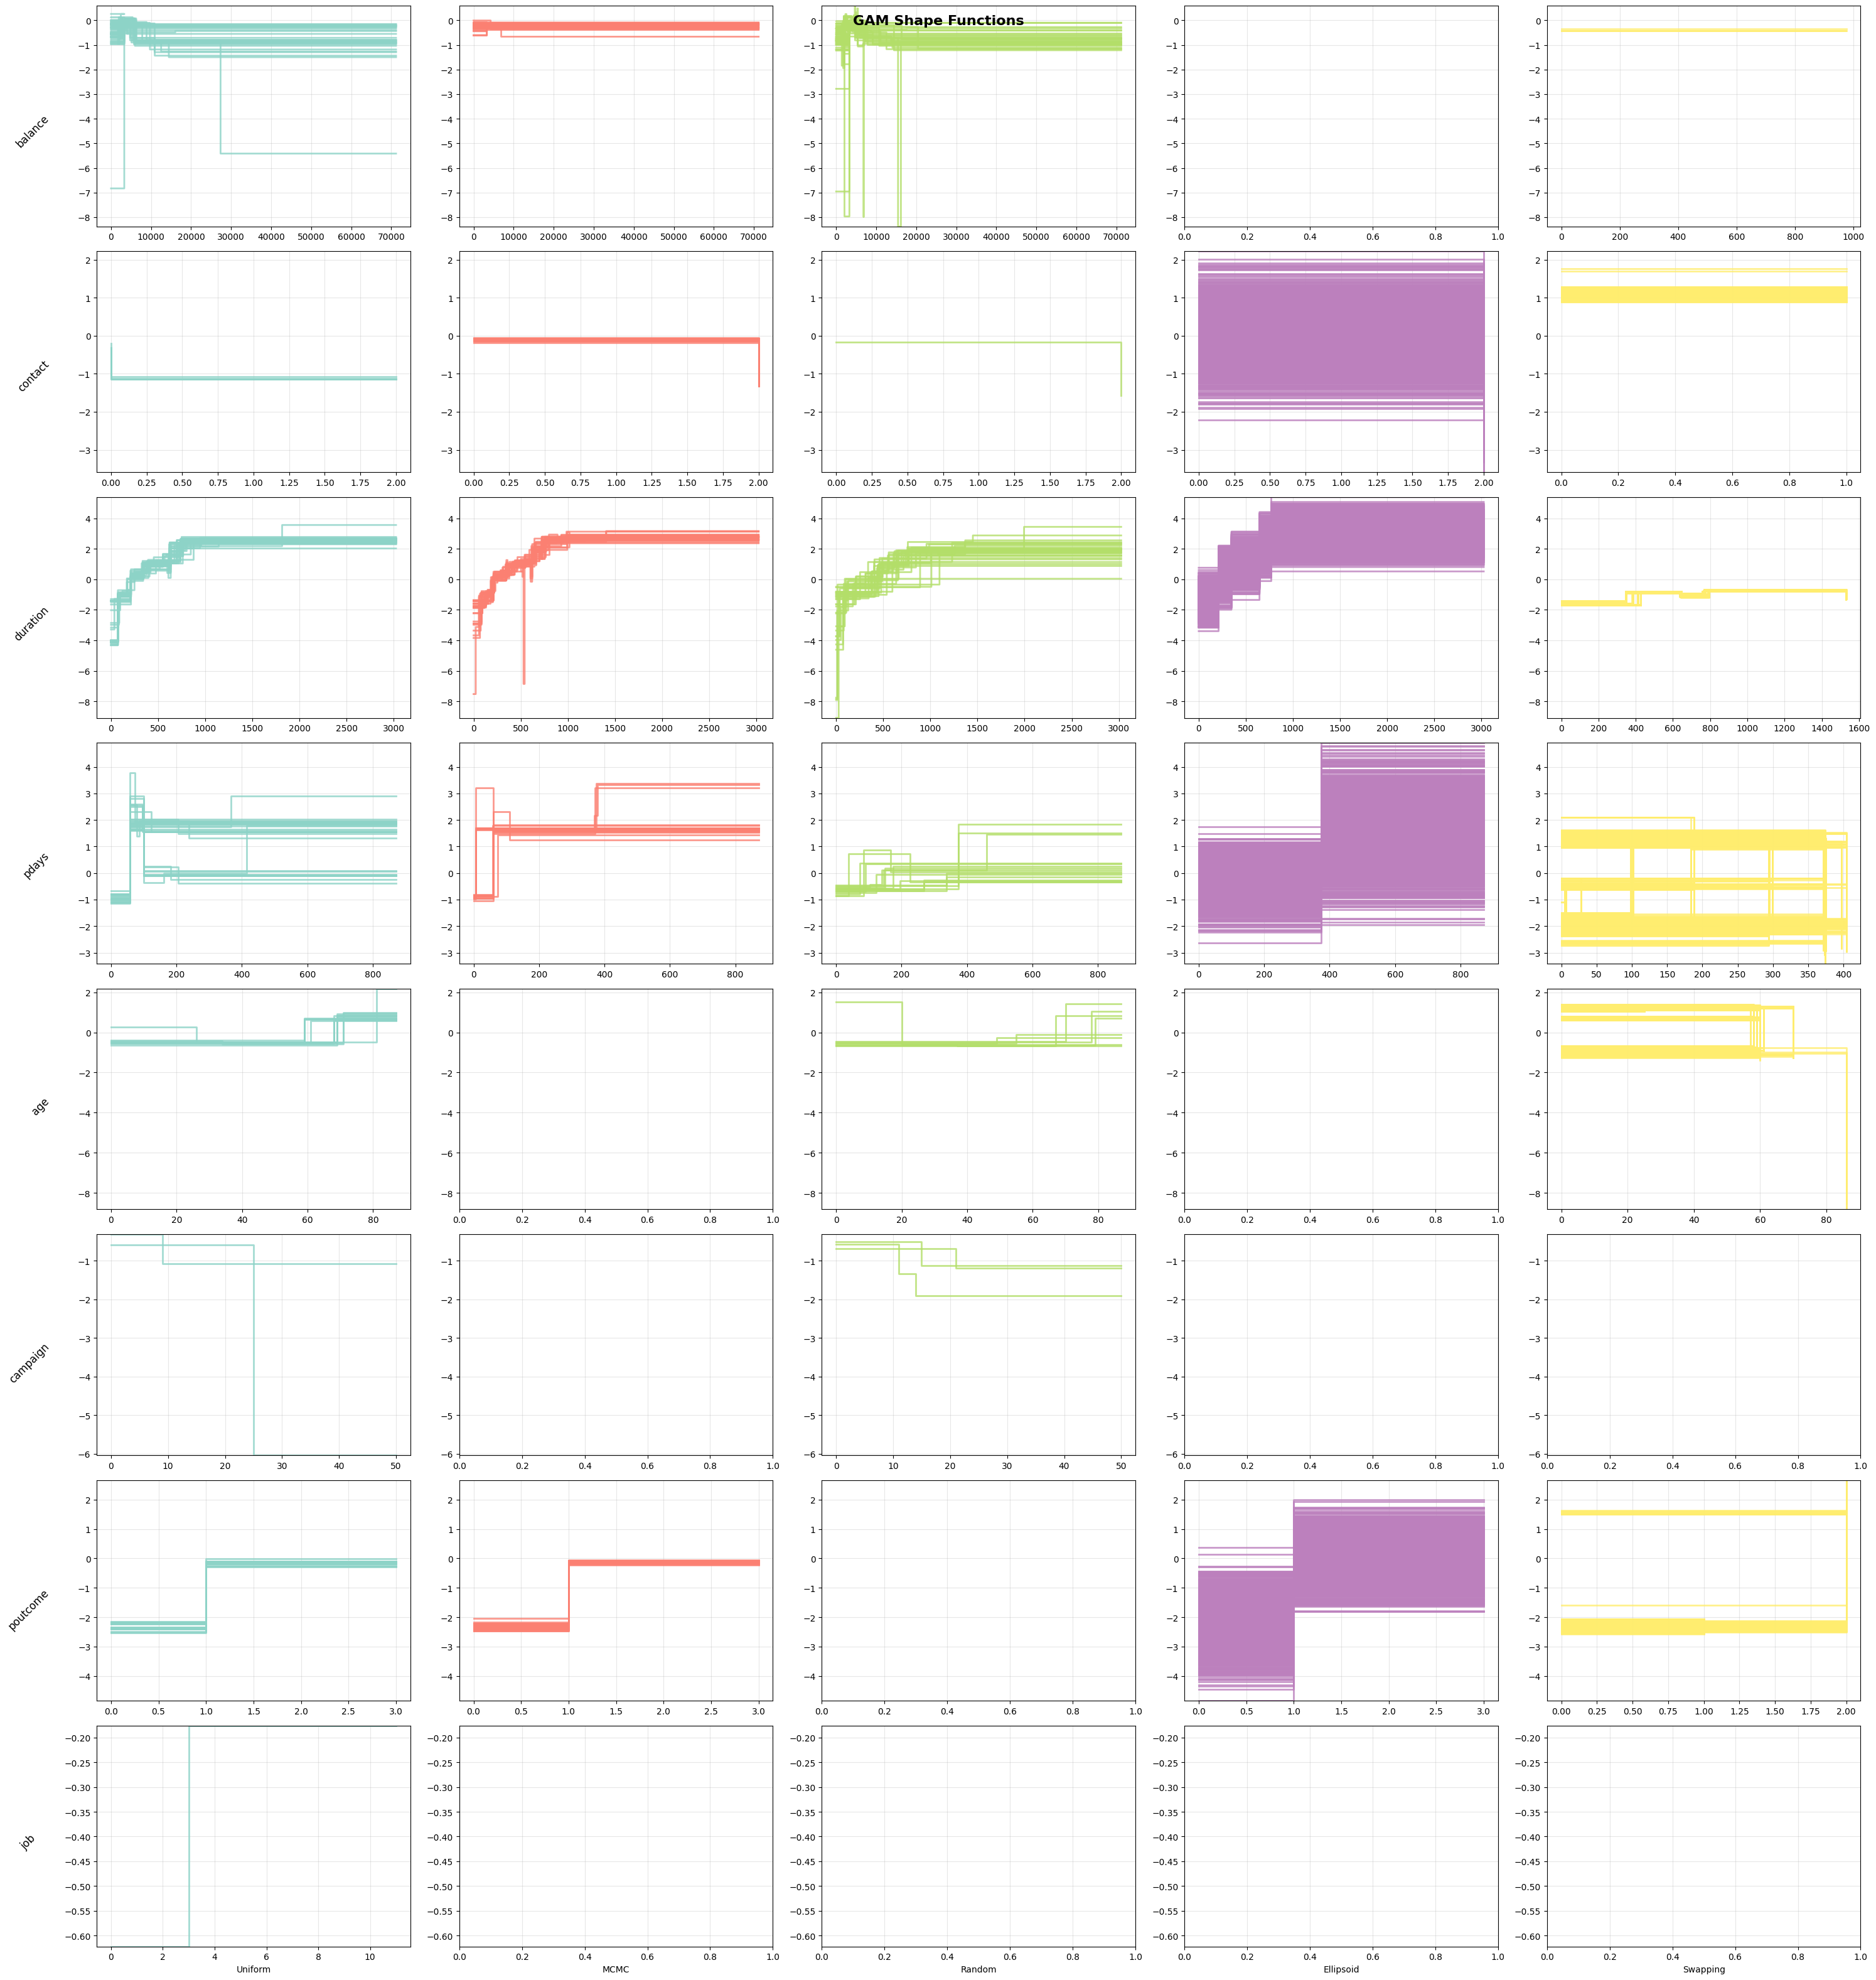

In [98]:
plotter = MultiPlotter(title=f"GAM Shape Functions")
plotter.add_shape_function(np.array(bin_header[1:]), binned_uniform_w_samples[:,1:], 'Uniform')
plotter.add_shape_function(np.array(bin_header[1:]), binned_mcmc_w_samples[:,1:], 'MCMC')
plotter.add_shape_function(np.array(bin_header[1:]), binned_random_w_samples[:,1:], 'Random')
plotter.add_shape_function(np.array(bin_header[1:]), ellipsoid_result.w_rset[:,1:], 'Ellipsoid')
plotter.add_shape_function(np.array(bin_header[1:]), swapping_result.w_rset[:,1:], 'Swapping')
fig = plotter.plot_shape_functions()

In [137]:
len(binned_uniform_w_samples[0].nonzero()[0]), len(binned_uniform_w_samples[0])

(3524, 3719)

In [107]:
support_set_metrics = [Metrics.inverse_IoU, Metrics.euclidean_distance, Metrics.inverse_cosine_similarity]
metric_results = []
for metric in support_set_metrics:
    print(metric.__name__)
    mr = []
    for w_rset in [binned_uniform_w_samples, binned_mcmc_w_samples, binned_random_w_samples, ellipsoid_result.w_rset, swapping_result.w_rset[:100,:]]:
        print('hi')
        average_diversity = Metrics.average_pairwise_diversity(w_rset, metric, limit=100)
        mr.append(average_diversity)
    metric_results.append(mr)

inverse_IoU
hi
hi
hi
hi
hi
euclidean_distance
hi
hi
hi
hi
hi
inverse_cosine_similarity
hi
hi
hi
hi
hi


In [96]:
ellipsoid_losses, _ = ModelUtils.get_loss(bin_X, y, ellipsoid_result.w_rset, loss_type='logistic', l2=0.001)
swapping_losses, _ = ModelUtils.get_loss(cum_X, y, swapping_result.w_rset, loss_type='logistic', l2=0.001)

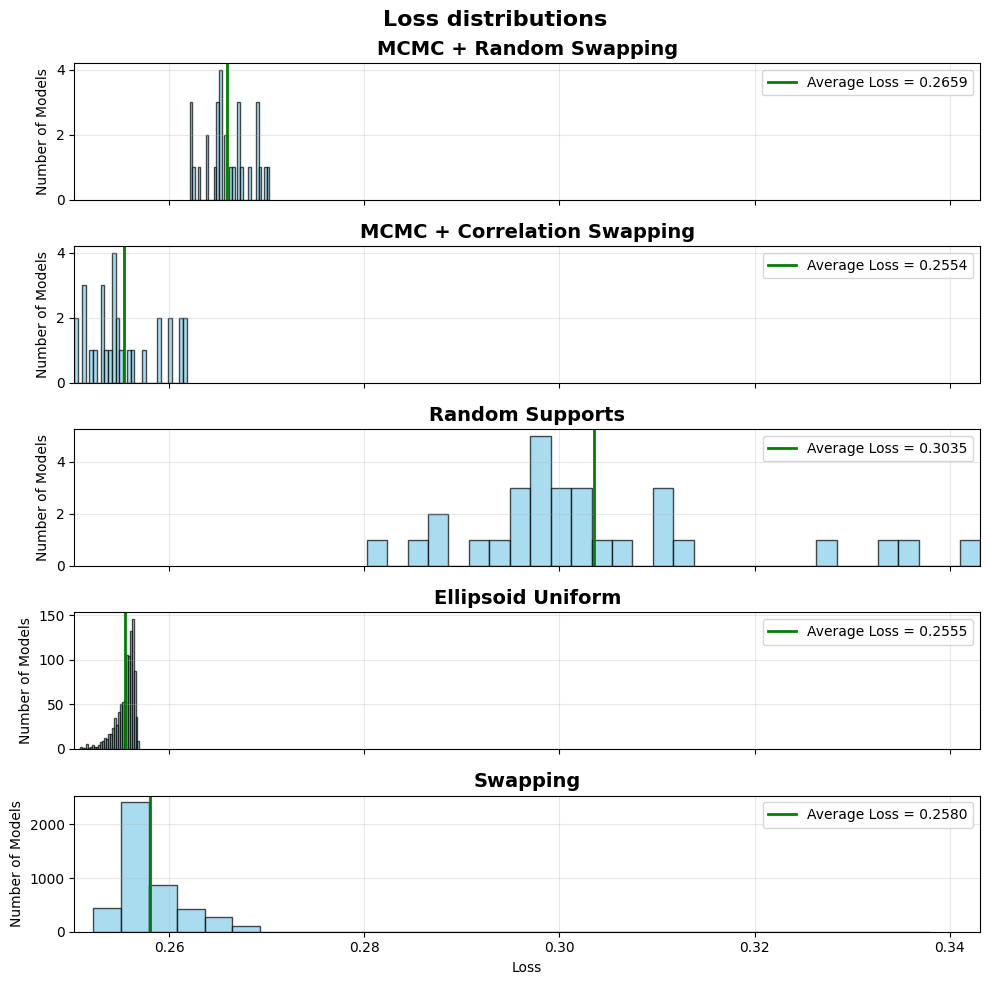

In [99]:
plotter = MultiPlotter(title=f"Loss distributions")
plotter.add_distribution(uniform_losses, 'MCMC + Random Swapping')
plotter.add_distribution(mcmc_losses, 'MCMC + Correlation Swapping')
plotter.add_distribution(random_losses, 'Random Supports')
plotter.add_distribution(ellipsoid_losses, 'Ellipsoid Uniform')
plotter.add_distribution(swapping_losses, 'Swapping')

fig = plotter.plot_distributions()

In [109]:
len(metric_results[0])

5

In [114]:
metric_results[0][1]

(0.2743238822655111, array([0.27432388, 0.27432388]))

In [130]:
i = 0
methods = ['MCMC + Random Swapping', 'MCMC + Correlation Swapping', 'Random Supports', 'Ellipsoid Uniform', 'Swapping']
support_set_metrics[i].__name__, metric_results[i]

('inverse_IoU',
 [(0.011535175538170463, array([0.01153518, 0.01153518])),
  (0.2743238822655111, array([0.27432388, 0.27432388])),
  (0.05323498098142228, array([0.05323498, 0.05323498])),
  (0.0, array([0., 0.])),
  (0.3508549740020328, array([0.35085497, 0.35085497]))])

In [ ]:
plotter = MultiPlotter(title=f"Loss distributions")
methods = 
plotter.add_bar(metric_results[0], methods)
plotter.add_bar(metric_results[0], methods)

fig = plotter.plot_bar_charts()

AttributeError: 'list' object has no attribute 'to_list'